# 03 - KerasTuner and KerasCV Augmentation

This notebook focuses on two practical ideas:

1. **Hyperparameter search** with KerasTuner
2. **Stronger image augmentation pipelines** using KerasCV / modern Keras vision augmentation layers

We keep the search space modest so the notebook remains realistic for Colab.


In [1]:
# Colab setup
%pip -q install -U tensorflow keras-tuner keras-cv pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 201.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 22.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 37.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import keras_cv

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("keras_tuner:", kt.__version__)
print("keras_cv:", keras_cv.__version__)


TensorFlow: 2.21.0
keras_tuner: 1.4.8
keras_cv: 0.9.0


## Dataset

We use a smaller CIFAR-10 subset so the tuner can actually finish in Colab without aging into a fossil.


In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.squeeze()
y_test = y_test.squeeze()

x_train = x_train[:18000].astype("float32")
y_train = y_train[:18000]
x_test = x_test[:3000].astype("float32")
y_test = y_test[:3000]

val_size = 3000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_tr, y_tr = x_train[:-val_size], y_train[:-val_size]

print(x_tr.shape, x_val.shape, x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step
(15000, 32, 32, 3) (3000, 32, 32, 3) (3000, 32, 32, 3)


In [5]:
AUTO = tf.data.AUTOTUNE
batch_size = 8

plain_train_ds = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)).shuffle(5000).batch(batch_size).prefetch(AUTO)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(batch_size).prefetch(AUTO)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size).prefetch(AUTO)


## Visualize KerasCV augmenters


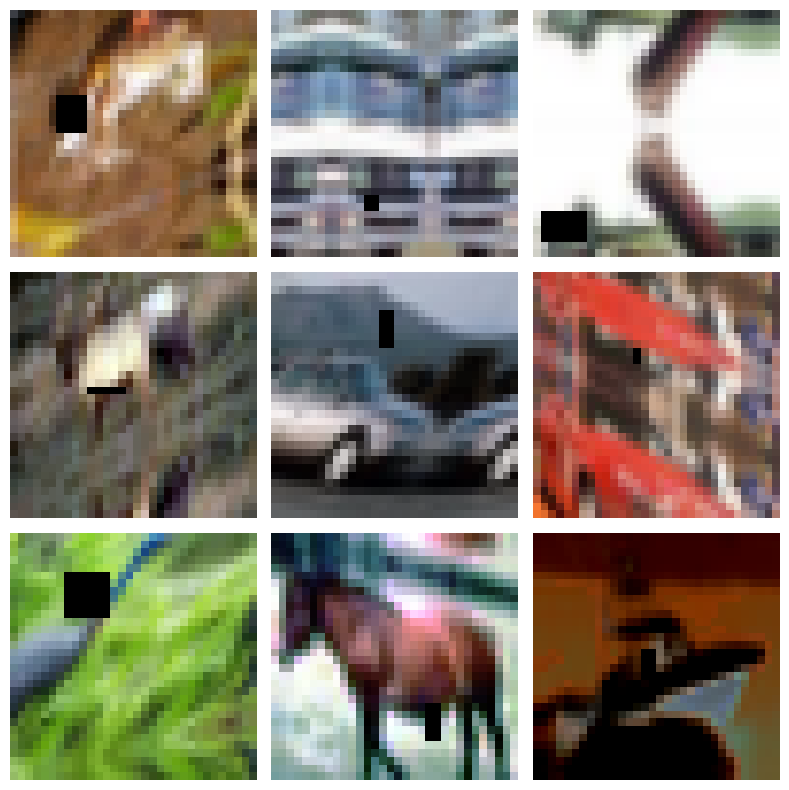

In [6]:
augmenter = keras.Sequential(
    [
        keras_cv.layers.RandAugment(value_range=(0, 255), augmentations_per_image=2, magnitude=0.5),
        keras_cv.layers.RandomCutout(height_factor=0.2, width_factor=0.2),
    ],
    name="kerascv_augmenter",
)

sample_images = x_tr[:9]
augmented = augmenter(sample_images)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, image in zip(axes.ravel(), augmented.numpy().astype("uint8")):
    ax.imshow(image)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [7]:
def make_augmented_dataset(images, labels, batch_size=128):
    ds = tf.data.Dataset.from_tensor_slices((images, labels)).shuffle(5000).batch(batch_size)

    def apply_aug(x, y):
        x = augmenter(x, training=True)
        x = tf.cast(x, tf.float32) / 255.0
        return x, y

    return ds.map(apply_aug, num_parallel_calls=AUTO).prefetch(AUTO)

def make_plain_dataset(images, labels, batch_size=128, training=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        ds = ds.shuffle(5000)
    ds = ds.batch(batch_size)
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=AUTO)
    return ds.prefetch(AUTO)

plain_train_ds = make_plain_dataset(x_tr, y_tr, training=True)
aug_train_ds = make_augmented_dataset(x_tr, y_tr)
val_ds = make_plain_dataset(x_val, y_val)
test_ds = make_plain_dataset(x_test, y_test)


## KerasTuner model builder


In [8]:
def build_tunable_model(hp):
    inputs = keras.Input(shape=(32, 32, 3))
    x = inputs

    for block_idx in range(hp.Int("num_blocks", 2, 3)):
        filters = hp.Choice(f"filters_{block_idx}", [32, 64, 96])
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(
        hp.Choice("dense_units", [128, 256, 384]),
        activation="relu",
    )(x)
    x = layers.Dropout(hp.Float("dropout", 0.2, 0.5, step=0.1))(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice("learning_rate", [1e-3, 5e-4, 3e-4])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [12]:
tuner = kt.Hyperband(
    build_tunable_model,
    objective="val_accuracy",
    max_epochs=4,
    factor=2,
    directory="tuner_runs",
    project_name="cifar10_keras_tuner",
    overwrite=True,
)


## Hyperparameter search on the plain dataset


In [13]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True,
)

tuner.search(
    plain_train_ds,
    validation_data=val_ds,
    epochs=4,
    callbacks=[early_stop],
    verbose=1,
)


Trial 15 Complete [00h 17m 09s]
val_accuracy: 0.31966665387153625

Best val_accuracy So Far: 0.4480000138282776
Total elapsed time: 01h 34m 31s


In [14]:
best_hp = tuner.get_best_hyperparameters(1)[0]
best_hp.values


{'num_blocks': 2,
 'filters_0': 32,
 'filters_1': 96,
 'dense_units': 256,
 'dropout': 0.4,
 'learning_rate': 0.0003,
 'filters_2': 96,
 'tuner/epochs': 4,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 0,
 'tuner/round': 0}

In [16]:
best_plain_model = tuner.hypermodel.build(best_hp)
plain_history = best_plain_model.fit(
    plain_train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[early_stop],
    verbose=1,
)
plain_test = best_plain_model.evaluate(test_ds, verbose=0)
plain_test


Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.3103 - loss: 1.9617 - val_accuracy: 0.1040 - val_loss: 2.3387
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.4441 - loss: 1.5360 - val_accuracy: 0.1537 - val_loss: 2.3242
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.5112 - loss: 1.3501 - val_accuracy: 0.1937 - val_loss: 2.1842


[2.134368419647217, 0.20666666328907013]

## Re-train the same best architecture with stronger augmentation

This isolates the effect of augmentation policy from the effect of architecture search.


In [18]:
best_aug_model = tuner.hypermodel.build(best_hp)
aug_history = best_aug_model.fit(
    aug_train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[early_stop],
    verbose=1,
)
aug_test = best_aug_model.evaluate(test_ds, verbose=0)
aug_test


Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.1565 - loss: 2.2788 - val_accuracy: 0.1543 - val_loss: 2.2718
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.2077 - loss: 2.1096 - val_accuracy: 0.1930 - val_loss: 2.1975


[2.261258602142334, 0.17133332788944244]

In [19]:
comparison = pd.DataFrame(
    [
        {"setting": "best_hp + plain_data", "test_loss": plain_test[0], "test_acc": plain_test[1]},
        {"setting": "best_hp + kerascv_aug", "test_loss": aug_test[0], "test_acc": aug_test[1]},
    ]
)
comparison


,setting,test_loss,test_acc
0,best_hp + plain_data,2.134368,0.206667
1,best_hp + kerascv_aug,2.261259,0.171333


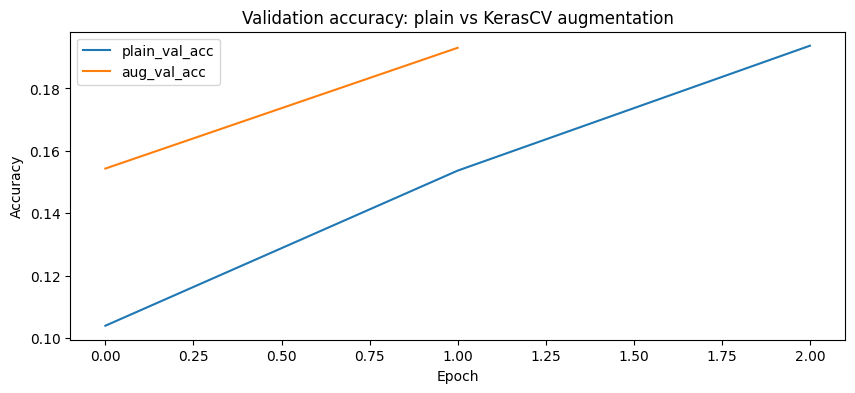

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(plain_history.history["val_accuracy"], label="plain_val_acc")
plt.plot(aug_history.history["val_accuracy"], label="aug_val_acc")
plt.title("Validation accuracy: plain vs KerasCV augmentation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


## What to discuss in the video

- The tuner searches over filters, dense size, dropout, and learning rate.
- Hyperparameter tuning and augmentation solve different problems:
  - tuning changes the model and optimizer settings
  - augmentation changes the effective training distribution
- KerasCV-style policies such as RandAugment and Cutout often improve robustness by forcing the model to handle nuisance variation.

This notebook is a nice bridge between classical regularization and stronger data-centric training.
